# 30-Day Hospital Readmission Risk Modeling
### Predictive Modeling and Intervention Capacity Analysis


### Modeling Objective

* **Prediction target:** 30-day readmission
* **Prediction point:** Discharge
* **Grain:** 1 row per admission
* **Prediction cohort:** Admissions resulting in discharge alive

Patients with `discharge_type = "Expired"` were excluded because they were not eligible to experience a subsequent 30-day readmission.

### Source

**BigQuery analytical table:**

`healthcare-readmission-505214.staging.feat_readmission_model_v2`

### Primary Question

> Among patients discharged alive, how well can the available admission, clinical, demographic, and discharge information distinguish patients who will be readmitted within 30 days from those who will not?

### Modeling Approach

Multiple predictive models were evaluated using the same held-out test set:

1. **Logistic Regression** — baseline and expanded feature sets
2. **Random Forest** — baseline and expanded feature sets
3. **XGBoost** — expanded feature set with individual ICD-10 indicators

Feature sets were progressively expanded to evaluate whether additional diagnosis information provided meaningful improvement beyond the baseline model.

### Modeling Population Refinement

The original analytical dataset contained admissions with a discharge disposition of `Expired`. These records were excluded before predictive model development because patients who died during the admission did not have an opportunity for a subsequent 30-day readmission.

After this refinement, the final modeling population consisted of **112,587 eligible admissions**.

The exclusion was applied before feature selection, model training, model evaluation, and risk-stratification analysis to ensure that the prediction target was clinically meaningful.

### Model Evaluation

Model discrimination was evaluated primarily using **ROC-AUC**. Because 30-day readmission is a relatively infrequent outcome, classification performance at a single 0.50 probability threshold was not treated as the primary basis for model selection.

For the selected model, additional evaluation was performed using **percentile-based risk stratification** to determine how many future readmissions could potentially be captured under different intervention-capacity scenarios.

### Business Application

The final objective is not simply to predict readmission. The model is intended to support a practical decision:

> **If clinical resources are limited, how many high-risk discharged patients should the hospital prioritize for potential intervention?**

Percentile-based risk stratification is therefore used to connect predictive performance with operational intervention capacity.


## Key Results at a Glance

| Metric | Result |
|---|---:|
| Eligible admissions | 112,587 |
| Test-set admissions | 22,518 |
| Test-set readmissions | 2,842 |
| Overall test-set readmission rate | 12.6% |
| Selected model | Logistic Regression |
| Selected model AUC | 0.7545 |
| Best AUC | 0.7554 |
| Incremental AUC from expanded ICD-10 features | +0.0008 |
| Top 5% risk-group lift | 3.83× |
| Readmissions captured in top 10% | 32.2% |
| Readmissions captured in top 20% | 50.7% |

Main conclusion: Additional diagnosis features produced minimal incremental discrimination. The simpler baseline Logistic Regression model was therefore selected for risk stratification because it provided nearly identical predictive performance with fewer features and greater interpretability.

## Notebook Roadmap
### This analysis follows five stages:

1. **Data Validation**
   - Verify admission-level grain
   - Check duplicates and missing values
   - Confirm target distribution

2. **Feature Preparation**
   - Create discharge timing features
   - Define baseline and expanded feature sets
   - Establish a consistent train/test framework

3. **Model Development**
   - Logistic Regression
   - Random Forest
   - XGBoost
   - Progressive feature expansion

4. **Model Comparison and Selection**
   - Compare ROC-AUC across models
   - Evaluate incremental value of additional features
   - Select a practical model based on performance and interpretability

5. **Risk Stratification**
   - Rank patients by predicted risk
   - Evaluate intervention-capacity scenarios
   - Translate model performance into operational implications

## Step 0: Import final analytical dataset from BigQuery


In [54]:
# Authenticate Colab with Google

from google.colab import auth
auth.authenticate_user()

In [55]:
# Import Libraries
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns


In [56]:
# Load the table from BigQuery

from google.cloud import bigquery


client = bigquery.Client(project="healthcare-readmission-505214")

query = """
SELECT *
FROM `healthcare-readmission-505214.staging.feat_readmission_model_v2`
"""

df = client.query(query).to_dataframe()

## Step 1: Inspect and Verify Dataset

In [57]:
df.head()

,admission_id,patient_id,age,gender,patient_state,bpl_card,insurance_type,comorbidity_count,prev_admissions,admit_date,...,has_K70,has_P22,has_A09,has_A15,has_J45,has_S06,has_N39,has_S72,has_C50,has_A41
0,6d6d617c-bfc9-46b8-9d23-1afe455ca099,dc4cb617-05e4-42e9-bf1d-59ffa117c58d,54,M,Telangana,False,ESI,1,1,2015-04-12,...,0,0,1,0,0,0,0,0,0,0
1,8d2dc481-88bb-455d-bd01-289aca28d9b7,481ad33b-34af-4686-a4ef-3ad6b2143b50,8,F,Haryana,False,None,0,0,2016-06-05,...,0,0,1,0,0,0,0,0,0,0
2,a854bfc3-4f34-4180-a962-13f5f0652ee6,b1dc0e95-421d-4baf-9ab5-16e181a7705b,43,F,West Bengal,False,Private,1,2,2022-02-09,...,0,0,1,0,0,0,0,0,0,0
3,e7986d86-eab7-48e8-afad-17dc6e0162c6,8b9cb301-e2bf-4965-9745-26d8e8504dc2,30,M,Rajasthan,False,None,1,0,2024-01-25,...,0,0,1,0,0,1,0,0,0,0
4,f98feb42-5fb3-4e60-93b1-7cbcadec9946,19159034-1687-4d81-8f1e-2d361176090e,16,F,Rajasthan,True,Ayushman,0,0,2018-06-04,...,0,0,1,0,0,0,0,0,0,0


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112587 entries, 0 to 112586
Data columns (total 79 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   admission_id               112587 non-null  object 
 1   patient_id                 112587 non-null  object 
 2   age                        112587 non-null  Int64  
 3   gender                     112587 non-null  object 
 4   patient_state              112587 non-null  object 
 5   bpl_card                   112587 non-null  boolean
 6   insurance_type             112587 non-null  object 
 7   comorbidity_count          112587 non-null  Int64  
 8   prev_admissions            112587 non-null  Int64  
 9   admit_date                 112587 non-null  dbdate 
 10  discharge_date             112587 non-null  dbdate 
 11  los_days                   112587 non-null  Int64  
 12  admit_type                 112587 non-null  object 
 13  ward_type                  11

In [59]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
admission_id,112587,112587,a72215c6-06a0-4289-93ad-76b44eead4ec,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient_id,112587,62923,dd0ca7f5-a2e4-4077-8602-49690edaca7e,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,112587.0,<NA>,<NA>,<NA>,48.125387,21.64336,0.0,36.0,51.0,63.0,95.0
gender,112587,3,M,57660,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient_state,112587,15,Maharashtra,12464,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
has_S06,112587.0,<NA>,<NA>,<NA>,0.04505,0.207414,0.0,0.0,0.0,0.0,1.0
has_N39,112587.0,<NA>,<NA>,<NA>,0.044943,0.20718,0.0,0.0,0.0,0.0,1.0
has_S72,112587.0,<NA>,<NA>,<NA>,0.044756,0.20677,0.0,0.0,0.0,0.0,1.0
has_C50,112587.0,<NA>,<NA>,<NA>,0.045369,0.208114,0.0,0.0,0.0,0.0,1.0


In [60]:
# Verify the important assumptions:
# - There is a total of 112,587 rows/ unique admission_id
# - No duplicates rows.
# - No missing values

print("Dataset validation")
print("-" * 50)

# Row and admission-level uniqueness
print(f"Total rows:              {len(df):,}")
print(f"Unique admission IDs:    {df['admission_id'].nunique():,}")
print(f"Duplicate admission IDs: {df['admission_id'].duplicated().sum():,}")

# Missing values
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("\nMissing values")
print("-" * 50)

if missing.empty:
    print("No missing values detected.")
else:
    print(missing)

Dataset validation
--------------------------------------------------
Total rows:              112,587
Unique admission IDs:    112,587
Duplicate admission IDs: 0

Missing values
--------------------------------------------------
No missing values detected.


In [61]:
# Check the target: readmiited_30d

target_summary = pd.DataFrame({
    "count": df["readmitted_30d"].value_counts(),
    "percentage": df["readmitted_30d"].value_counts(normalize=True) * 100
})

target_summary

,count,percentage
readmitted_30d,,
0,98377,87.378649
1,14210,12.621351


## Step 2a: Feature Engineering, datetime

In [62]:
# Convert BigQuery date columns to pandas datetime

df["admit_date"] = pd.to_datetime(df["admit_date"])
df["discharge_date"] = pd.to_datetime(df["discharge_date"])

print(df[["admit_date", "discharge_date"]].dtypes)

admit_date        datetime64[ns]
discharge_date    datetime64[ns]
dtype: object


In [63]:
# ============================================================
# Create discharge day-of-week feature
# Prediction point: Discharge
# ============================================================

df["discharge_day_of_week"] = df["discharge_date"].dt.day_name()

print(df[[
    "discharge_date",
    "discharge_day_of_week"
]].head())

print("\nDischarge day of week:")
print(df["discharge_day_of_week"].value_counts())

  discharge_date discharge_day_of_week
0     2015-04-16              Thursday
1     2016-06-08             Wednesday
2     2022-02-10              Thursday
3     2024-01-26                Friday
4     2018-06-06             Wednesday

Discharge day of week:
discharge_day_of_week
Monday       16229
Thursday     16158
Friday       16145
Sunday       16064
Tuesday      16021
Saturday     16014
Wednesday    15956
Name: count, dtype: int64


## 2b. Feature Inventory and Feature Selection

In [64]:
# ============================================================
# Feature Inventory
# ============================================================

feature_groups = {
    "Identifiers": [
        "admission_id",
        "patient_id",
        "hospital_id"
    ],

    "Targets": [
        "readmitted_30d",
        "readmitted_7d"
    ],

    "Dates": [
        "admit_date"
    ],

    "Numeric": [
        "age",
        "comorbidity_count",
        "prev_admissions",
        "los_days",
        "num_procedures",
        "charlson_index",
        "hba1c",
        "creatinine",
        "haemoglobin",
        "systolic_bp",
        "beds",
        "diagnosis_count",
        "secondary_diagnosis_count"
    ],

    "Binary diagnosis indicators": [
        "has_cardiovascular",
        "has_endocrine",
        "has_infectious",
        "has_respiratory",
        "has_gastrointestinal",
        "has_neoplasm",
        "has_neurological",
        "has_injury",
        "has_genitourinary",
        "has_obstetric",
        "has_perinatal"
    ],

    "Categorical": [
        "gender",
        "patient_state",
        "bpl_card",
        "insurance_type",
        "admit_type",
        "ward_type",
        "discharge_type",
        "hospital_state",
        "tier",
        "teaching",
        "primary_diag_category",
        "discharge_day_of_week"
    ],

    "Primary diagnosis detail": [
        "primary_icd10_code",
        "primary_diag_desc"
    ]
}

for group, columns in feature_groups.items():
    print(f"\n{group} ({len(columns)} columns)")
    print("-" * 50)
    for col in columns:
        print(f"  {col}")


Identifiers (3 columns)
--------------------------------------------------
  admission_id
  patient_id
  hospital_id

Targets (2 columns)
--------------------------------------------------
  readmitted_30d
  readmitted_7d

Dates (1 columns)
--------------------------------------------------
  admit_date

Numeric (13 columns)
--------------------------------------------------
  age
  comorbidity_count
  prev_admissions
  los_days
  num_procedures
  charlson_index
  hba1c
  creatinine
  haemoglobin
  systolic_bp
  beds
  diagnosis_count
  secondary_diagnosis_count

Binary diagnosis indicators (11 columns)
--------------------------------------------------
  has_cardiovascular
  has_endocrine
  has_infectious
  has_respiratory
  has_gastrointestinal
  has_neoplasm
  has_neurological
  has_injury
  has_genitourinary
  has_obstetric
  has_perinatal

Categorical (12 columns)
--------------------------------------------------
  gender
  patient_state
  bpl_card
  insurance_type
  admit_type


## Step 3.1. Model 1_ Feature Selection

In [65]:
# ============================================================
# Model 1 — Baseline Feature Set
# Prediction point: Discharge
# Target: 30-day readmission
# ============================================================

model_1_features = [
    # Patient
    "age",
    "patient_state",
    "bpl_card",
    "insurance_type",
    "comorbidity_count",
    "prev_admissions",

    # Admission / operational
    "los_days",
    "admit_type",
    "ward_type",
    "discharge_type",
    "num_procedures",

    # Clinical
    "charlson_index",
    "creatinine",
    "haemoglobin",
    "systolic_bp",

    # Discharge timing
    "discharge_day_of_week",
   ]

target = "readmitted_30d"

X = df[model_1_features].copy()
y = df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (112587, 16)
y shape: (112587,)


In [66]:
# Convert boolean features to integer indicators
X["bpl_card"] = X["bpl_card"].astype(int)


print(X[["bpl_card"]].dtypes)

bpl_card    int64
dtype: object


## Step 3.2. Model 1_Transformation and Preprocessing Pipeline

In [67]:
# Model 1 — Feature Grouping for Preprocessing

numeric_features = [
    "age",
    "comorbidity_count",
    "prev_admissions",
    "los_days",
    "num_procedures",
    "charlson_index",
    "creatinine",
    "haemoglobin",
    "systolic_bp",
      ]

categorical_features = [
    "patient_state",
    "insurance_type",
    "discharge_type",
    "admit_type",
    "ward_type",
    "discharge_day_of_week",
   ]

binary_features = [
    "bpl_card",
  ]

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Binary features:", len(binary_features))
print("Total:", len(numeric_features) + len(categorical_features) + len(binary_features))

Numeric features: 9
Categorical features: 6
Binary features: 1
Total: 16


In [68]:
# Build the preprocessing transformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        ("bin", "passthrough", binary_features)
    ]
)

Note: Class Imbalance Handling

Because 30-day readmission is less frequent than non-readmission, class imbalance was addressed during model development.

- Logistic Regression: `class_weight="balanced"`
- Random Forest: `class_weight="balanced"`
- XGBoost: `scale_pos_weight` based on the training-set class ratio

These approaches increase the relative importance of the minority readmission class during model fitting. Model discrimination was subsequently evaluated on the same held-out test set.

## Step 3.3. Train/Test split

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=88
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (90069, 16)
Test set: (22518, 16)

Training target distribution:
readmitted_30d
0    0.873786
1    0.126214
Name: proportion, dtype: Float64

Test target distribution:
readmitted_30d
0    0.87379
1    0.12621
Name: proportion, dtype: Float64


Note: Train/Test Split and Evaluation-Set Integrity

A stratified 80/20 split was used to preserve the proportion of 30-day readmissions in both the training and evaluation sets.

The same 20% held-out evaluation set was used across the model comparisons to provide a consistent basis for comparing model discrimination.

Feature preprocessing was fitted within each model pipeline using the training data only. The held-out evaluation data were not used during preprocessing or model fitting.

## 3.4.1. Model 1a_Basline Logistic Regression Model Training

In [70]:
# Model 1a — Logistic Regression Baseline

clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "clf",
            LogisticRegression(
                class_weight="balanced",
                solver="liblinear",
                random_state=88 ))])


# Train a Logistic Regression Model
model_1a = clf.fit(X_train, y_train)
print('Model_1a trained.')

Model_1a trained.


## Step 3.4.2: Model 1a_Logistic Regression Model Evaluation

AUC: 0.755


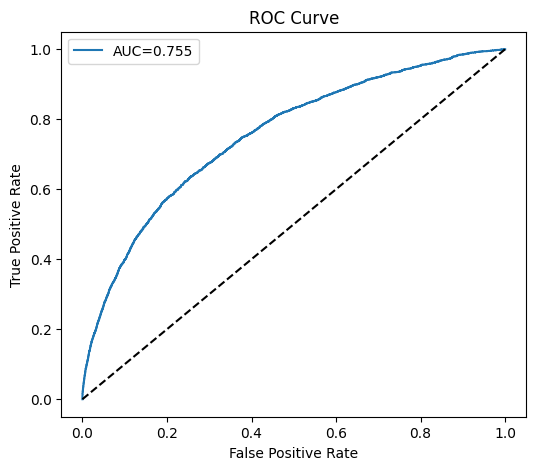

Confusion matrix (0.5 threshold):
 [[13983  5693]
 [  954  1888]]

Classification report:
               precision    recall  f1-score   support

         0.0       0.94      0.71      0.81     19676
         1.0       0.25      0.66      0.36      2842

    accuracy                           0.70     22518
   macro avg       0.59      0.69      0.59     22518
weighted avg       0.85      0.70      0.75     22518



In [71]:
# Predictions and probabilities
y_prob_1a = model_1a.predict_proba(X_test)[:,1]
y_pred_1a = model_1a.predict(X_test)

# ROC and AUC
auc_1a = roc_auc_score(y_test, y_prob_1a)
print('AUC:', round(auc_1a,3))
fpr, tpr, thresholds = roc_curve(y_test, y_prob_1a)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC={auc_1a:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


# Confusion matrix at 0.5 threshold
cm = confusion_matrix(y_test, y_pred_1a)
print('Confusion matrix (0.5 threshold):\n', cm)
print('\nClassification report:\n', classification_report(y_test, y_pred_1a))

## 3.5.1. Model 1b_Random Forest Model Training

In [72]:
# ============================================================
# Model 1b — Random Forest
# Same feature set as Model 1a
# Prediction point: Discharge
# Target: 30-day readmission
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=88,
                n_jobs=-1 ))])

# Train Random Forest
rf_model.fit(X_train, y_train)

print("Model 1b — Random Forest trained.")

Model 1b — Random Forest trained.


## 3.5.2 Model 1b_ Random Forest Model Evaluation

AUC: 0.738


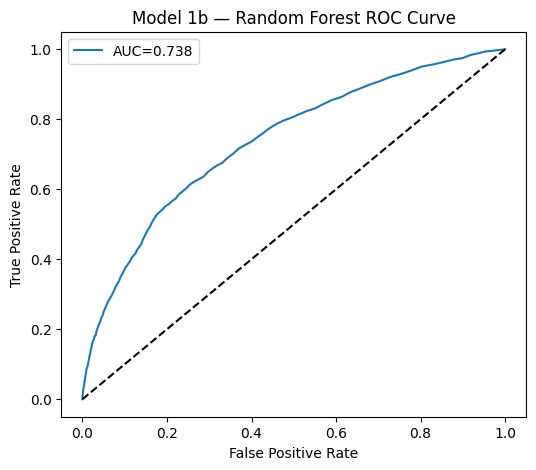

Confusion matrix (0.5 threshold):
 [[19552   124]
 [ 2670   172]]

Classification report:
               precision    recall  f1-score   support

         0.0       0.88      0.99      0.93     19676
         1.0       0.58      0.06      0.11      2842

    accuracy                           0.88     22518
   macro avg       0.73      0.53      0.52     22518
weighted avg       0.84      0.88      0.83     22518



In [73]:
# ============================================================
# Model 1b — Random Forest Evaluation
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

# Predictions and probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = rf_model.predict(X_test)

# ROC and AUC
auc_1b = roc_auc_score(y_test, y_prob_rf)

print("AUC:", round(auc_1b, 3))

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, label=f"AUC={auc_1b:.3f}")
plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model 1b — Random Forest ROC Curve")
plt.legend()
plt.show()


# Confusion matrix at 0.5 threshold
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion matrix (0.5 threshold):\n", cm_rf)

print(
    "\nClassification report:\n",
    classification_report(y_test, y_pred_rf)
)

## Step 4.1. Model 2_Feature Selection

In [74]:
# ============================================================
# Model 2 — Enhanced Clinical Feature Set
# Baseline features + ICD-10 diagnosis-category indicators
# Prediction point: Discharge
# Target: 30-day readmission
# ============================================================

model_2_features = model_1_features + [
    "has_cardiovascular",
    "has_endocrine",
    "has_infectious",
    "has_respiratory",
    "has_gastrointestinal",
    "has_neoplasm",
    "has_neurological",
    "has_injury",
    "has_genitourinary",
    "has_obstetric",
    "has_perinatal"
]

X_model2 = df[model_2_features].copy()

print("Model 2 feature count:", len(model_2_features))


Model 2 feature count: 27


In [75]:
# ============================================================
# Model 2 — Feature Groups for Preprocessing
# Model 1 baseline features + ICD-10 diagnosis-category indicators
# ============================================================

numeric_features_model2 = [
    "age",
    "comorbidity_count",
    "prev_admissions",
    "los_days",
    "num_procedures",
    "charlson_index",
    "creatinine",
    "haemoglobin",
    "systolic_bp"
]

categorical_features_model2 = [
    "patient_state",
    "insurance_type",
    "discharge_type",
    "admit_type",
    "ward_type",
    "discharge_day_of_week"
]

binary_features_model2 = [
    "bpl_card",

    # ICD-10 diagnosis-category indicators
    "has_cardiovascular",
    "has_endocrine",
    "has_infectious",
    "has_respiratory",
    "has_gastrointestinal",
    "has_neoplasm",
    "has_neurological",
    "has_injury",
    "has_genitourinary",
    "has_obstetric",
    "has_perinatal"
]

print("Numeric:", len(numeric_features_model2))
print("Categorical:", len(categorical_features_model2))
print("Binary:", len(binary_features_model2))
print(
    "Total:",
    len(numeric_features_model2)
    + len(categorical_features_model2)
    + len(binary_features_model2)
)

Numeric: 9
Categorical: 6
Binary: 12
Total: 27


## Step 4.2. Train/Test Split

In [76]:
X_model2_train = X_model2.loc[X_train.index]
X_model2_test = X_model2.loc[X_test.index]

print("Model 2 training:", X_model2_train.shape)
print("Model 2 test:", X_model2_test.shape)


Model 2 training: (90069, 27)
Model 2 test: (22518, 27)


## 4.3 Preprocessing and Transformation


In [77]:
# ============================================================
# Model 2 — Preprocessing Transformer
# ============================================================

preprocessor_model2 = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features_model2
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_model2
        ),
        (
            "bin",
            "passthrough",
            binary_features_model2
        )
    ]
)

print("Model 2 preprocessor created.")

Model 2 preprocessor created.


## Step 4.4.1 Model 2a_Create Pipeline and Model Training

In [78]:
# ============================================================
# Model 2a — Logistic Regression
# Enhanced Clinical Feature Set
# Prediction point: Discharge
# Target: 30-day readmission
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model_2a = Pipeline(
    steps=[
        ("preprocessor", preprocessor_model2),
        (
            "clf",
            LogisticRegression(
                class_weight="balanced",
                solver="liblinear",
                random_state=88
            )
        )
    ]
)

# Train Model 2a
model_2a.fit(X_model2_train, y_train)

print("Model 2a trained.")

Model 2a trained.


## Step 4.4.2 Evaluate Model 2a

AUC: 0.755


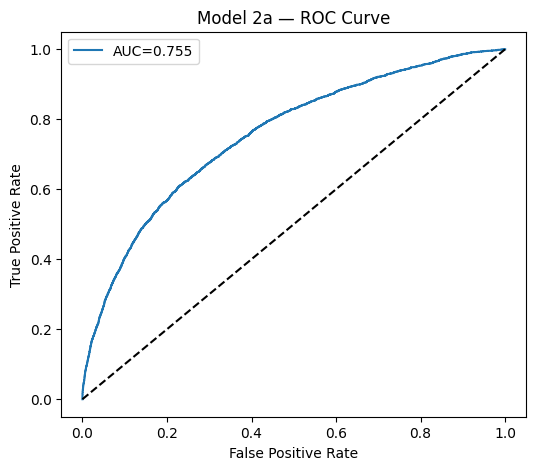

Confusion matrix (0.5 threshold):
 [[14008  5668]
 [  956  1886]]

Classification report:
               precision    recall  f1-score   support

         0.0       0.94      0.71      0.81     19676
         1.0       0.25      0.66      0.36      2842

    accuracy                           0.71     22518
   macro avg       0.59      0.69      0.59     22518
weighted avg       0.85      0.71      0.75     22518



In [79]:
# ============================================================
# Model 2a — Evaluation
# Logistic Regression + Diagnosis Category Indicators
# Target: 30-day readmission
# ============================================================


# Predictions and probabilities
y_prob_2a = model_2a.predict_proba(X_model2_test)[:, 1]
y_pred_2a = model_2a.predict(X_model2_test)

# ------------------------------------------------------------
# ROC and AUC
# ------------------------------------------------------------

auc_2a = roc_auc_score(y_test, y_prob_2a)

print("AUC:", round(auc_2a, 3))

fpr_2a, tpr_2a, thresholds_2a = roc_curve(y_test, y_prob_2a)

plt.figure(figsize=(6, 5))
plt.plot(fpr_2a, tpr_2a, label=f"AUC={auc_2a:.3f}")
plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model 2a — ROC Curve")
plt.legend()
plt.show()

# ------------------------------------------------------------
# Confusion Matrix — 0.50 Threshold
# ------------------------------------------------------------

cm_2a = confusion_matrix(y_test, y_pred_2a)

print("Confusion matrix (0.5 threshold):\n", cm_2a)

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print(
    "\nClassification report:\n",
    classification_report(y_test, y_pred_2a)
)

## Step 4.5.1. Model 2b_ Create Pipeline and Model Training

In [80]:
# ============================================================
# Model 2b — Random Forest
# Enhanced Clinical Feature Set
# Baseline + ICD-10 Diagnosis Category Indicators
# Prediction point: Discharge
# Target: 30-day readmission
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

model_2b = Pipeline(
    steps=[
        ("preprocessor", preprocessor_model2),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=88,
                n_jobs=-1
            )
        )
    ]
)

# Train Model 2b
model_2b.fit(X_model2_train, y_train)

print("Model 2b trained.")

Model 2b trained.


## Step 4.5.2. Model 2b Evaluation

AUC: 0.736


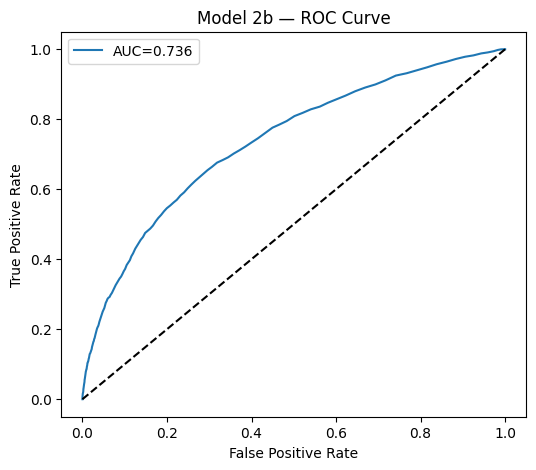

Confusion matrix (0.5 threshold):
 [[19589    87]
 [ 2710   132]]

Classification report:
               precision    recall  f1-score   support

         0.0       0.88      1.00      0.93     19676
         1.0       0.60      0.05      0.09      2842

    accuracy                           0.88     22518
   macro avg       0.74      0.52      0.51     22518
weighted avg       0.84      0.88      0.83     22518



In [81]:
# ============================================================
# Model 2b — Evaluation
# ============================================================

# Predictions and probabilities
y_prob_2b = model_2b.predict_proba(X_model2_test)[:, 1]
y_pred_2b = model_2b.predict(X_model2_test)

# ROC and AUC
auc_2b = roc_auc_score(y_test, y_prob_2b)

print("AUC:", round(auc_2b, 3))

fpr_2b, tpr_2b, thresholds_2b = roc_curve(y_test, y_prob_2b)

plt.figure(figsize=(6, 5))
plt.plot(fpr_2b, tpr_2b, label=f"AUC={auc_2b:.3f}")
plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model 2b — ROC Curve")
plt.legend()
plt.show()

# Confusion matrix at 0.50 threshold
cm_2b = confusion_matrix(y_test, y_pred_2b)

print("Confusion matrix (0.5 threshold):\n", cm_2b)

# Classification report
print(
    "\nClassification report:\n",
    classification_report(y_test, y_pred_2b)
)

## Step 5.1 Model 3_Feature Selection

In [82]:
# ============================================================
# Model 3 — Diagnosis Burden Feature Set
# Baseline features + Diagnosis Burden
# Prediction point: Discharge
# Target: 30-day readmission
# ============================================================

model_3_features = model_1_features + [
    "diagnosis_count",
    "secondary_diagnosis_count"
]

X_model3 = df[model_3_features].copy()
y_model3 = df["readmitted_30d"].copy()

print("X_model3 shape:", X_model3.shape)
print("y_model3 shape:", y_model3.shape)

X_model3 shape: (112587, 18)
y_model3 shape: (112587,)


In [83]:
# ============================================================
# Model 3 — Feature Groups for Preprocessing
# Model 1 baseline features + Diagnosis Burden
# ============================================================

numeric_features_model3 = [
    # Model 1 numeric features
    "age",
    "comorbidity_count",
    "prev_admissions",
    "los_days",
    "num_procedures",
    "charlson_index",
    "creatinine",
    "haemoglobin",
    "systolic_bp",

    # Diagnosis burden
    "diagnosis_count",
    "secondary_diagnosis_count"
]

categorical_features_model3 = [
    # Model 1 categorical features
    "patient_state",
    "insurance_type",
    "discharge_type",
    "admit_type",
    "ward_type",
    "discharge_day_of_week"
]

binary_features_model3 = [
    "bpl_card"
]

print("Numeric:", len(numeric_features_model3))
print("Categorical:", len(categorical_features_model3))
print("Binary:", len(binary_features_model3))

print(
    "Total:",
    len(numeric_features_model3)
    + len(categorical_features_model3)
    + len(binary_features_model3)
)

Numeric: 11
Categorical: 6
Binary: 1
Total: 18


## Step 5.2 Train/Test Split; Define X , y

In [84]:
X_model3_train = X_model3.loc[X_train.index]
X_model3_test = X_model3.loc[X_test.index]

print("Model 3 training:", X_model3_train.shape)
print("Model 3 test:", X_model3_test.shape)

Model 3 training: (90069, 18)
Model 3 test: (22518, 18)


## Step 5.3 Preprocessing and Transformation

In [85]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_model3 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_model3),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_model3
        ),
        ("bin", "passthrough", binary_features_model3)
    ]
)

## Step 5.4.1 Model 3a_ Create Pipeline and Model Training

In [86]:
# ============================================================
# Model 3a — Logistic Regression
# Baseline + Diagnosis Burden Features
# Prediction point: Discharge
# Target: 30-day readmission
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model_3a = Pipeline(
    steps=[
        ("preprocessor", preprocessor_model3),
        (
            "clf",
            LogisticRegression(
                class_weight="balanced",
                solver="liblinear",
                random_state=88
            )
        )
    ]
)

# Train Model 3a
model_3a.fit(
    X_model3_train,
    y_train
)

print("Model 3a trained.")

Model 3a trained.


## Step 5.4.2. Model 3a_Evaluation

AUC: 0.754


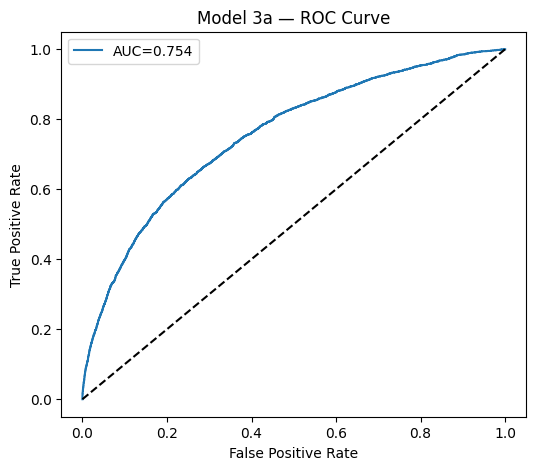

Confusion matrix (0.5 threshold):
 [[14031  5645]
 [  957  1885]]

Classification report:
               precision    recall  f1-score   support

         0.0       0.94      0.71      0.81     19676
         1.0       0.25      0.66      0.36      2842

    accuracy                           0.71     22518
   macro avg       0.59      0.69      0.59     22518
weighted avg       0.85      0.71      0.75     22518



In [87]:
# ============================================================
# Model 3a — Evaluation
# Logistic Regression + Diagnosis Burden
# Target: 30-day readmission
# ============================================================

# Predictions and probabilities
y_prob_3a = model_3a.predict_proba(X_model3_test)[:, 1]
y_pred_3a = model_3a.predict(X_model3_test)

# ------------------------------------------------------------
# ROC and AUC
# ------------------------------------------------------------

auc_3a = roc_auc_score(y_test, y_prob_3a)

print("AUC:", round(auc_3a, 3))

fpr_3a, tpr_3a, thresholds_3a = roc_curve(
    y_test,
    y_prob_3a
)

plt.figure(figsize=(6, 5))
plt.plot(
    fpr_3a,
    tpr_3a,
    label=f"AUC={auc_3a:.3f}"
)
plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model 3a — ROC Curve")
plt.legend()
plt.show()

# ------------------------------------------------------------
# Confusion Matrix — 0.50 Threshold
# ------------------------------------------------------------

cm_3a = confusion_matrix(
    y_test,
    y_pred_3a
)

print(
    "Confusion matrix (0.5 threshold):\n",
    cm_3a
)

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print(
    "\nClassification report:\n",
    classification_report(
        y_test,
        y_pred_3a
    )
)

## Step 5.5.1 Model 3b_Create Pipeline and Model Training

In [88]:
# ============================================================
# Model 3b — Random Forest
# Baseline + Diagnosis Burden Features
# Prediction point: Discharge
# Target: 30-day readmission
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

model_3b = Pipeline(
    steps=[
        ("preprocessor", preprocessor_model3),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=88,
                n_jobs=-1
            )
        )
    ]
)

# Train Model 3b
model_3b.fit(
    X_model3_train,
    y_train
)

print("Model 3b trained.")

Model 3b trained.


## Step 5.5.2 Model 3b_Evaluation

AUC: 0.733


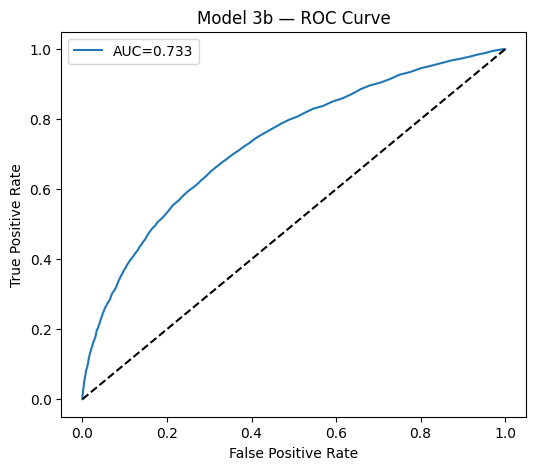

Confusion matrix (0.5 threshold):
 [[19546   130]
 [ 2656   186]]

Classification report:
               precision    recall  f1-score   support

         0.0       0.88      0.99      0.93     19676
         1.0       0.59      0.07      0.12      2842

    accuracy                           0.88     22518
   macro avg       0.73      0.53      0.53     22518
weighted avg       0.84      0.88      0.83     22518



In [89]:
# ============================================================
# Model 3b — Evaluation
# Random Forest + Diagnosis Burden
# Target: 30-day readmission
# ============================================================

# Predictions and probabilities
y_prob_3b = model_3b.predict_proba(X_model3_test)[:, 1]
y_pred_3b = model_3b.predict(X_model3_test)

# ------------------------------------------------------------
# ROC and AUC
# ------------------------------------------------------------

auc_3b = roc_auc_score(y_test, y_prob_3b)

print("AUC:", round(auc_3b, 3))

fpr_3b, tpr_3b, thresholds_3b = roc_curve(
    y_test,
    y_prob_3b
)

plt.figure(figsize=(6, 5))
plt.plot(
    fpr_3b,
    tpr_3b,
    label=f"AUC={auc_3b:.3f}"
)

plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model 3b — ROC Curve")
plt.legend()
plt.show()

# ------------------------------------------------------------
# Confusion Matrix — 0.50 Threshold
# ------------------------------------------------------------

cm_3b = confusion_matrix(
    y_test,
    y_pred_3b
)

print(
    "Confusion matrix (0.5 threshold):\n",
    cm_3b
)

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print(
    "\nClassification report:\n",
    classification_report(
        y_test,
        y_pred_3b
    )
)

## Step 6.1 Model 4_ Feature Selection

In [90]:
# ============================================================
# Model 4 — Individual ICD-10 Feature Set
# Baseline features + 34 individual ICD-10 indicators
# Prediction point: Discharge
# Target: 30-day readmission
# ============================================================

icd10_features = [
    "has_E10",
    "has_E11",
    "has_E87",
    "has_I21",
    "has_I48",
    "has_I10",
    "has_I50",
    "has_N18",
    "has_K57",
    "has_G40",
    "has_K80",
    "has_G35",
    "has_J18",
    "has_J44",
    "has_C18",
    "has_I63",
    "has_C34",
    "has_J96",
    "has_T14",
    "has_B54",
    "has_O34",
    "has_A91",
    "has_O80",
    "has_P07",
    "has_K70",
    "has_P22",
    "has_A09",
    "has_A15",
    "has_J45",
    "has_S06",
    "has_N39",
    "has_S72",
    "has_C50",
    "has_A41"
]

print("Number of ICD-10 indicators:", len(icd10_features))

Number of ICD-10 indicators: 34


In [91]:
# ============================================================
# Model 4 — Feature Groups for Preprocessing
# Model 1 baseline features + 34 individual ICD-10 indicators
# ============================================================

numeric_features_model4 = [
    # Model 1 numeric features
    "age",
    "comorbidity_count",
    "prev_admissions",
    "los_days",
    "num_procedures",
    "charlson_index",
    "creatinine",
    "haemoglobin",
    "systolic_bp"
]

categorical_features_model4 = [
    # Model 1 categorical features
    "patient_state",
    "insurance_type",
    "discharge_type",
    "admit_type",
    "ward_type",
    "discharge_day_of_week"
]

binary_features_model4 = [
    # Model 1 binary feature
    "bpl_card",

    # Individual ICD-10 indicators
    "has_E10",
    "has_E11",
    "has_E87",
    "has_I21",
    "has_I48",
    "has_I10",
    "has_I50",
    "has_N18",
    "has_K57",
    "has_G40",
    "has_K80",
    "has_G35",
    "has_J18",
    "has_J44",
    "has_C18",
    "has_I63",
    "has_C34",
    "has_J96",
    "has_T14",
    "has_B54",
    "has_O34",
    "has_A91",
    "has_O80",
    "has_P07",
    "has_K70",
    "has_P22",
    "has_A09",
    "has_A15",
    "has_J45",
    "has_S06",
    "has_N39",
    "has_S72",
    "has_C50",
    "has_A41"
]

print("Numeric:", len(numeric_features_model4))
print("Categorical:", len(categorical_features_model4))
print("Binary:", len(binary_features_model4))

print(
    "Total:",
    len(numeric_features_model4)
    + len(categorical_features_model4)
    + len(binary_features_model4)
)

Numeric: 9
Categorical: 6
Binary: 35
Total: 50


In [92]:
# ============================================================
# Model 4 — Feature Selection
# Baseline + 34 individual ICD-10 indicators
# ============================================================

model_4_features = model_1_features + icd10_features

X_model4 = df[model_4_features].copy()

print("X_model4 shape:", X_model4.shape)

X_model4 shape: (112587, 50)


In [93]:
# ============================================================
# Validate Model 4 ICD-10 features
# ============================================================

missing_icd_features = [
    col for col in icd10_features
    if col not in df.columns
]

print("Missing ICD-10 feature columns:", missing_icd_features)
print("Number of missing ICD-10 features:", len(missing_icd_features))

Missing ICD-10 feature columns: []
Number of missing ICD-10 features: 0


## Step 6.2. Train/Test split; Define X, y

In [94]:
X_model4_train = X_model4.loc[X_train.index]
X_model4_test = X_model4.loc[X_test.index]

print("Model 4 training:", X_model4_train.shape)
print("Model 4 test:", X_model4_test.shape)

Model 4 training: (90069, 50)
Model 4 test: (22518, 50)


## Step 6.3 Transformation and Preprocessing

In [95]:
# ============================================================
# Model 4a — Preprocessing Transformer
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_model4 = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features_model4
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_model4
        ),
        (
            "bin",
            "passthrough",
            binary_features_model4
        )
    ]
)

print("Model 4 preprocessing transformer created.")

Model 4 preprocessing transformer created.


## 6.4.1 Model 4a_Create Pipeline and Model Training

In [96]:
# ============================================================
# Model 4a — Logistic Regression
# Baseline + 34 Individual ICD-10 Indicators
# Prediction point: Discharge
# Target: 30-day readmission
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model_4a = Pipeline(
    steps=[
        ("preprocessor", preprocessor_model4),
        (
            "clf",
            LogisticRegression(
                class_weight="balanced",
                solver="liblinear",
                random_state=88
            )
        )
    ]
)

# ------------------------------------------------------------
# Train Model 4a
# ------------------------------------------------------------

model_4a.fit(
    X_model4_train,
    y_train
)

print("Model 4a trained successfully.")

Model 4a trained successfully.


## 6.4.2 Model 4a_Evaluation

AUC: 0.755


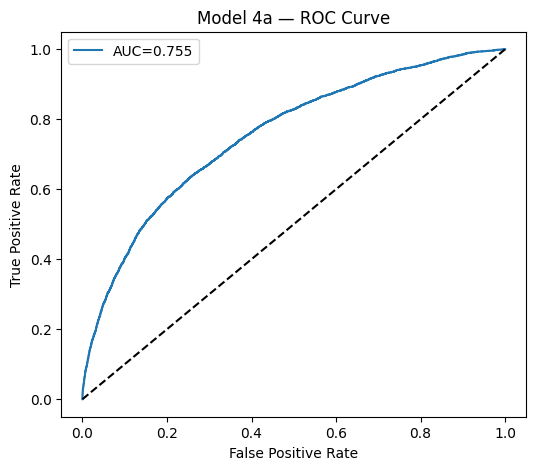

Confusion matrix (0.5 threshold):
 [[13995  5681]
 [  958  1884]]

Classification report:
               precision    recall  f1-score   support

         0.0       0.94      0.71      0.81     19676
         1.0       0.25      0.66      0.36      2842

    accuracy                           0.71     22518
   macro avg       0.59      0.69      0.59     22518
weighted avg       0.85      0.71      0.75     22518



In [97]:
# ============================================================
# Model 4a — Evaluation
# Logistic Regression + 34 Individual ICD-10 Indicators
# Target: 30-day readmission
# ============================================================

# Predictions and probabilities
y_prob_4a = model_4a.predict_proba(X_model4_test)[:, 1]
y_pred_4a = model_4a.predict(X_model4_test)

# ------------------------------------------------------------
# ROC and AUC
# ------------------------------------------------------------

auc_4a = roc_auc_score(y_test, y_prob_4a)

print("AUC:", round(auc_4a, 3))

fpr_4a, tpr_4a, thresholds_4a = roc_curve(y_test, y_prob_4a)

plt.figure(figsize=(6, 5))
plt.plot(
    fpr_4a,
    tpr_4a,
    label=f"AUC={auc_4a:.3f}"
)
plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model 4a — ROC Curve")
plt.legend()
plt.show()

# ------------------------------------------------------------
# Confusion Matrix — 0.50 Threshold
# ------------------------------------------------------------

cm_4a = confusion_matrix(y_test, y_pred_4a)

print("Confusion matrix (0.5 threshold):\n", cm_4a)

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print(
    "\nClassification report:\n",
    classification_report(y_test, y_pred_4a)
)

In [98]:
# ============================================================
# Model 4a — Feature Importance
# Logistic Regression + 34 Individual ICD-10 Indicators
# Prediction point: Discharge
# Target: 30-day readmission
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Extract fitted preprocessor and logistic regression model
# ------------------------------------------------------------

preprocessor_4a = model_4a.named_steps["preprocessor"]
classifier_4a = model_4a.named_steps["clf"]

# ------------------------------------------------------------
# Get feature names after preprocessing
# ------------------------------------------------------------

feature_names_4a = preprocessor_4a.get_feature_names_out()

# ------------------------------------------------------------
# Get logistic regression coefficients
# ------------------------------------------------------------

coefficients_4a = classifier_4a.coef_[0]

# ------------------------------------------------------------
# Create feature importance dataframe
# ------------------------------------------------------------

feature_importance_4a = pd.DataFrame({
    "feature": feature_names_4a,
    "coefficient": coefficients_4a
})

# ------------------------------------------------------------
# Calculate absolute coefficient
# Used to rank strength of association
# ------------------------------------------------------------

feature_importance_4a["abs_coefficient"] = (
    feature_importance_4a["coefficient"].abs()
)

# ------------------------------------------------------------
# Calculate odds ratio
# OR > 1  = higher odds of readmission
# OR < 1  = lower odds of readmission
# ------------------------------------------------------------

feature_importance_4a["odds_ratio"] = np.exp(
    feature_importance_4a["coefficient"]
)

# ------------------------------------------------------------
# Add direction of association
# ------------------------------------------------------------

feature_importance_4a["direction"] = np.where(
    feature_importance_4a["coefficient"] > 0,
    "Higher readmission risk",
    "Lower readmission risk"
)

# ------------------------------------------------------------
# Reorder columns
# ------------------------------------------------------------

feature_importance_4a = feature_importance_4a[
    [
        "feature",
        "coefficient",
        "odds_ratio",
        "abs_coefficient",
        "direction"
    ]
]

# ------------------------------------------------------------
# Sort by absolute coefficient
# Strongest associations first
# ------------------------------------------------------------

feature_importance_4a = feature_importance_4a.sort_values(
    "coefficient",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# Display top 20 features
# ------------------------------------------------------------

display(feature_importance_4a.head(20))

,feature,coefficient,odds_ratio,abs_coefficient,direction
0,num__los_days,0.329350,1.390065,0.329350,Higher readmission risk
1,num__comorbidity_count,0.324980,1.384004,0.324980,Higher readmission risk
2,cat__discharge_type_LAMA,0.295873,1.344300,0.295873,Higher readmission risk
3,cat__ward_type_ICU,0.276555,1.318579,0.276555,Higher readmission risk
4,bin__bpl_card,0.222628,1.249356,0.222628,Higher readmission risk
5,num__prev_admissions,0.177265,1.193947,0.177265,Higher readmission risk
6,num__age,0.146149,1.157369,0.146149,Higher readmission risk
7,cat__admit_type_Emergency,0.135045,1.144588,0.135045,Higher readmission risk
8,cat__insurance_type_Ayushman,0.131741,1.140812,0.131741,Higher readmission risk
9,num__charlson_index,0.119264,1.126667,0.119264,Higher readmission risk


Note: Logistic Regression Coefficient Analysis and Odds Ratios

For Model 4a, logistic regression coefficients were examined to understand which features were most strongly associated with the predicted odds of 30-day readmission.

For standardized numeric variables, the odds ratio represents the change in predicted odds associated with approximately a one-standard-deviation increase in the feature, holding other model features constant.

For binary and categorical variables, interpretation depends on the corresponding reference category.

These coefficients represent model associations and should not be interpreted as causal effects.

## 6.5.1 Model 4b_Create Pipeline and Model Training

In [99]:
# ============================================================
# Model 4b — Random Forest
# Baseline + 34 Individual ICD-10 Indicators
# Prediction point: Discharge
# Target: 30-day readmission
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

model_4b = Pipeline(
    steps=[
        ("preprocessor", preprocessor_model4),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=88,
                n_jobs=-1
            )
        )
    ]
)

# ------------------------------------------------------------
# Train Model 4b
# ------------------------------------------------------------

model_4b.fit(
    X_model4_train,
    y_train
)

print("Model 4b trained successfully.")

Model 4b trained successfully.


## 6.5.2 Model 4b_Evaluation

AUC: 0.741


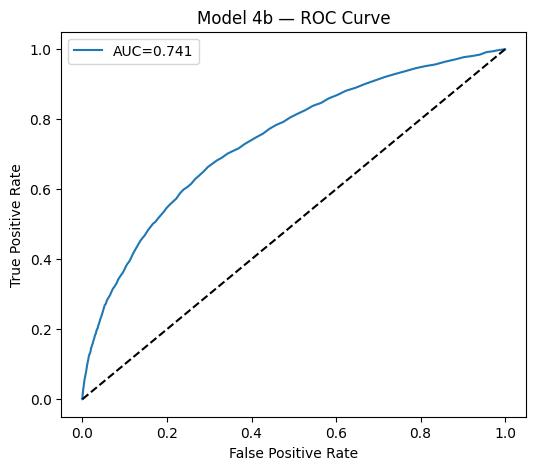

Confusion matrix (0.5 threshold):
 [[19590    86]
 [ 2700   142]]

Classification report:
               precision    recall  f1-score   support

         0.0       0.88      1.00      0.93     19676
         1.0       0.62      0.05      0.09      2842

    accuracy                           0.88     22518
   macro avg       0.75      0.52      0.51     22518
weighted avg       0.85      0.88      0.83     22518



In [100]:
# ============================================================
# Model 4b — Evaluation
# Random Forest + 34 Individual ICD-10 Indicators
# ============================================================

# Predictions and probabilities
y_prob_4b = model_4b.predict_proba(X_model4_test)[:, 1]
y_pred_4b = model_4b.predict(X_model4_test)

# ------------------------------------------------------------
# ROC and AUC
# ------------------------------------------------------------

auc_4b = roc_auc_score(y_test, y_prob_4b)

print("AUC:", round(auc_4b, 3))

fpr_4b, tpr_4b, thresholds_4b = roc_curve(
    y_test,
    y_prob_4b
)

plt.figure(figsize=(6, 5))
plt.plot(
    fpr_4b,
    tpr_4b,
    label=f"AUC={auc_4b:.3f}"
)
plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model 4b — ROC Curve")
plt.legend()
plt.show()

# ------------------------------------------------------------
# Confusion Matrix — 0.50 Threshold
# ------------------------------------------------------------

cm_4b = confusion_matrix(y_test, y_pred_4b)

print(
    "Confusion matrix (0.5 threshold):\n",
    cm_4b
)

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print(
    "\nClassification report:\n",
    classification_report(y_test, y_pred_4b)
)

## Step 7. Model 5_XGBoost

In [101]:
!pip install xgboost -q

In [102]:
# ============================================================
# Model 5 — XGBoost
# Feature Set: Model 4
# Baseline + 34 Individual ICD-10 Indicators
# Prediction point: Discharge
# Target: 30-day readmission
# ============================================================

from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# ------------------------------------------------------------
# XGBoost preprocessing
# ------------------------------------------------------------
# No StandardScaler needed for tree-based boosting.
# Categorical variables are one-hot encoded.
# Binary variables pass through unchanged.

preprocessor_xgb = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_model4
        ),
        (
            "bin",
            "passthrough",
            binary_features_model4
        ),
        (
            "num",
            "passthrough",
            numeric_features_model4
        )
    ]
)

print("XGBoost preprocessing transformer created.")

XGBoost preprocessing transformer created.


In [103]:
# ============================================================
# Model 5 — XGBoost Pipeline
# ============================================================

model_5 = Pipeline(
    steps=[
        ("preprocessor", preprocessor_xgb),
        (
            "xgb",
            XGBClassifier(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=6.93,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=88,
                n_jobs=-1
            )
        )
    ]
)

# ------------------------------------------------------------
# Train Model 5
# ------------------------------------------------------------

model_5.fit(
    X_model4_train,
    y_train
)

print("Model 5 — XGBoost trained successfully.")

Model 5 — XGBoost trained successfully.


AUC: 0.75


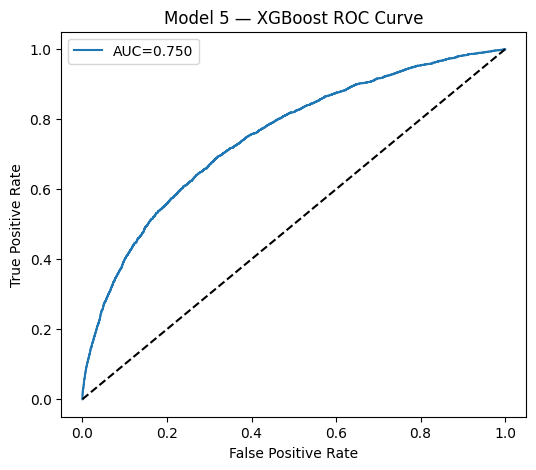

Confusion matrix (0.5 threshold):
 [[14441  5235]
 [ 1036  1806]]

Classification report:
               precision    recall  f1-score   support

         0.0       0.93      0.73      0.82     19676
         1.0       0.26      0.64      0.37      2842

    accuracy                           0.72     22518
   macro avg       0.59      0.68      0.59     22518
weighted avg       0.85      0.72      0.76     22518



In [104]:
# ============================================================
# Model 5 — Evaluation
# XGBoost + 34 Individual ICD-10 Indicators
# Target: 30-day readmission
# ============================================================

# Predictions and probabilities
y_prob_5 = model_5.predict_proba(X_model4_test)[:, 1]
y_pred_5 = model_5.predict(X_model4_test)

# ------------------------------------------------------------
# ROC and AUC
# ------------------------------------------------------------

auc_5 = roc_auc_score(y_test, y_prob_5)

print("AUC:", round(auc_5, 3))

fpr_5, tpr_5, thresholds_5 = roc_curve(
    y_test,
    y_prob_5
)

plt.figure(figsize=(6, 5))
plt.plot(
    fpr_5,
    tpr_5,
    label=f"AUC={auc_5:.3f}"
)
plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model 5 — XGBoost ROC Curve")
plt.legend()
plt.show()

# ------------------------------------------------------------
# Confusion Matrix — 0.50 Threshold
# ------------------------------------------------------------

cm_5 = confusion_matrix(y_test, y_pred_5)

print(
    "Confusion matrix (0.5 threshold):\n",
    cm_5
)

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print(
    "\nClassification report:\n",
    classification_report(y_test, y_pred_5)
)

## Step 8: Model Comparison, Selection and next step:

In [105]:
# ============================================================
# Final Model Comparison — Models 1a through 5
# ============================================================

model_results = pd.DataFrame({
    "Model": [
        "1a",
        "1b",
        "2a",
        "2b",
        "3a",
        "3b",
        "4a",
        "4b",
        "5"
    ],

    "Algorithm": [
        "Logistic Regression",
        "Random Forest",
        "Logistic Regression",
        "Random Forest",
        "Logistic Regression",
        "Random Forest",
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Feature_Set": [
        "Baseline",
        "Baseline",
        "+ ICD-10 Categories",
        "+ ICD-10 Categories",
        "+ Diagnosis Burden",
        "+ Diagnosis Burden",
        "+ 34 Individual ICD-10",
        "+ 34 Individual ICD-10",
        "+ 34 Individual ICD-10"
    ],

    "AUC": [
        auc_1a,
        auc_1b,
        auc_2a,
        auc_2b,
        auc_3a,
        auc_3b,
        auc_4a,
        auc_4b,
        auc_5
    ]
})

model_results = model_results.sort_values(
    "AUC",
    ascending=False
).reset_index(drop=True)

model_results

,Model,Algorithm,Feature_Set,AUC
0,4a,Logistic Regression,+ 34 Individual ICD-10,0.755377
1,2a,Logistic Regression,+ ICD-10 Categories,0.754771
2,1a,Logistic Regression,Baseline,0.754548
3,3a,Logistic Regression,+ Diagnosis Burden,0.754433
4,5,XGBoost,+ 34 Individual ICD-10,0.749630
5,4b,Random Forest,+ 34 Individual ICD-10,0.740834
6,1b,Random Forest,Baseline,0.737583
7,2b,Random Forest,+ ICD-10 Categories,0.736213
8,3b,Random Forest,+ Diagnosis Burden,0.733131


### Model Comparison

Model performance was compared across Logistic Regression, Random Forest, and XGBoost using the same held-out test set and progressively expanded feature sets. Patients with `discharge_type = "Expired"` were excluded before predictive modeling because they were not eligible to experience a subsequent 30-day readmission.

Following this refinement, Logistic Regression demonstrated the strongest discrimination across the evaluated models, with AUC values ranging from 0.7544 to 0.7554. XGBoost achieved an AUC of 0.7498, while Random Forest models achieved lower AUC values ranging from 0.7331 to 0.7408.

Among the Logistic Regression models, Model 4a, which incorporated 34 individual ICD-10 indicators, achieved the highest AUC (0.7554). However, its improvement over the simplified baseline Model 1a (AUC = 0.7545) was only 0.0008. This represents very limited incremental discriminatory value relative to the additional feature complexity.

The ICD-10 category model (Model 2a) achieved an AUC of 0.7548, while the diagnosis-burden model (Model 3a) achieved an AUC of 0.7544. These results similarly indicate that the additional diagnosis features provided little improvement in overall discrimination beyond the baseline feature set.

XGBoost was evaluated because boosting methods can capture nonlinear relationships and interactions. However, its AUC of 0.7498 did not outperform Logistic Regression. Random Forest consistently demonstrated lower discrimination.

### Model Selection

**Model 1a — Logistic Regression using the simplified baseline feature set — was selected as the preferred model for risk stratification.**

Although Model 4a achieved the highest AUC, the improvement over Model 1a was negligible (ΔAUC = 0.0008). Model 1a therefore provides essentially equivalent discrimination with fewer features and greater interpretability.

This makes Model 1a the more appropriate model for a clinically oriented risk-stratification application, where transparency, simplicity, and practical implementation are important.

The additional ICD-10 and diagnosis-burden analyses remain useful for understanding factors associated with readmission risk, even though they provided limited incremental improvement in predictive discrimination.


### Next Step:
Evaluate the selected Model 1a using percentile-based risk stratification. Patients are ranked from highest to lowest predicted risk, and intervention-capacity scenarios are evaluated by examining the proportion of future readmissions captured within the highest-risk 5%, 10%, 15%, 20%, and 25% of patients.

Hospitals have finite resources for intervention. This analysis provides a practical framework for understanding how many high-risk patients would need to be targeted under different capacity scenarios and how much of the observed readmission burden could potentially be captured.

In [106]:
# ============================================================
# Model 1a — Percentile-Based Risk Stratification
# Selected Model: Simplified Logistic Regression
# Target: 30-day readmission
# ============================================================

import numpy as np

# ------------------------------------------------------------
# Create evaluation dataframe
# ------------------------------------------------------------

risk_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted_risk": y_prob_1a
})

# Rank patients from highest to lowest predicted risk
risk_df = risk_df.sort_values(
    "predicted_risk",
    ascending=False
).reset_index(drop=True)


# Inspect the evluation dataframe
print(risk_df.head())

# ------------------------------------------------------------
# Overall readmission rate
# ------------------------------------------------------------

overall_readmission_rate = risk_df["actual"].mean()

print(
    "Overall readmission rate:",
    round(overall_readmission_rate * 100, 2),
    "%"
)

# ------------------------------------------------------------
# Evaluate different intervention capacities
# ------------------------------------------------------------

percentiles = [0.05, 0.10, 0.15, 0.20, 0.25]

results = []

total_readmissions = risk_df["actual"].sum()
total_patients = len(risk_df)

for p in percentiles:

    # Number of patients the hospital can intervene on
    n_flagged = int(np.ceil(total_patients * p))

    # Highest-risk patients
    flagged = risk_df.iloc[:n_flagged]

    # Actual readmissions captured
    readmissions_captured = flagged["actual"].sum()

    # Percentage of all readmissions captured
    capture_rate = (
        readmissions_captured / total_readmissions
    )

    # Precision
    precision = (
        readmissions_captured / n_flagged
    )

    # Readmission rate among flagged patients
    flagged_readmission_rate = flagged["actual"].mean()

    # Lift
    lift = (
        flagged_readmission_rate
        / overall_readmission_rate
    )

    results.append({
        "intervention_capacity": f"Top {int(p * 100)}%",
        "patients_flagged": n_flagged,
        "readmissions_captured": int(readmissions_captured),
        "capture_rate": capture_rate,
        "precision": precision,
        "flagged_readmission_rate": flagged_readmission_rate,
        "lift": lift
    })

# ------------------------------------------------------------
# Create results table
# ------------------------------------------------------------

percentile_results = pd.DataFrame(results)

# Convert rates to percentages
percentile_results["capture_rate"] *= 100
percentile_results["precision"] *= 100
percentile_results["flagged_readmission_rate"] *= 100

# Round for readability
percentile_results["capture_rate"] = (
    percentile_results["capture_rate"].round(1)
)

percentile_results["precision"] = (
    percentile_results["precision"].round(1)
)

percentile_results["flagged_readmission_rate"] = (
    percentile_results["flagged_readmission_rate"].round(1)
)

percentile_results["lift"] = (
    percentile_results["lift"].round(2)
)

percentile_results

   actual  predicted_risk
0       1        0.999054
1       1        0.989927
2       1        0.981178
3       1        0.981043
4       1        0.980936
Overall readmission rate: 12.62 %


,intervention_capacity,patients_flagged,readmissions_captured,capture_rate,precision,flagged_readmission_rate,lift
0,Top 5%,1126,545,19.2,48.4,48.4,3.83
1,Top 10%,2252,916,32.2,40.7,40.7,3.22
2,Top 15%,3378,1199,42.2,35.5,35.5,2.81
3,Top 20%,4504,1441,50.7,32.0,32.0,2.53
4,Top 25%,5630,1637,57.6,29.1,29.1,2.30


##Percentile-Based Risk Stratification
###Purpose

The predictive model ranks eligible discharged patients from highest to lowest predicted risk of 30-day readmission. Percentile-based analysis was used to determine how much of the future readmission burden could potentially be identified if the hospital has limited capacity to intervene.

Rather than selecting an arbitrary probability threshold, this approach allows hospital leadership to evaluate different intervention-capacity scenarios—for example, targeting the highest-risk 5%, 10%, 15%, 20%, or 25% of patients.

This helps answer a practical operational question: If the hospital can intervene with only a limited proportion of discharged patients, how much of the observed readmission burden could be concentrated within those highest-risk groups?

###Key Findings

Among the 22,518 eligible patients in the test set, 2,842 experienced a 30-day readmission. The model successfully concentrated higher-risk patients toward the top of its ranking.

Note: Refer to the output table above.

The overall 30-day readmission rate among eligible patients was 12.6%. In contrast, the highest-risk 5% had an observed readmission rate of 48.4%, representing a 3.83× lift over the overall rate.

For example, targeting the highest-risk 10% would focus intervention resources on 2,252 patients while capturing 32.2% of observed readmissions. Expanding intervention to the top 20% would capture approximately half (50.7%) of observed readmissions, but would require intervention for twice as many patients.

###Implications for Hospital Decision-Making

The results provide hospital leadership with a resource-versus-impact framework.

A hospital with very limited intervention capacity could focus on the highest-risk 5%. A hospital with greater capacity could expand to the top 10–20% to capture a larger proportion of the readmission burden.

There is no single universally optimal percentile. The appropriate intervention capacity should ultimately be determined by available clinical resources, intervention cost, and the acceptable balance between patients targeted and readmissions captured.

The percentile analysis therefore supports a management decision rather than prescribing a specific threshold.

###Important Limitation and Next Step

This analysis evaluates risk identification, not intervention effectiveness. The model identifies patients who historically had higher risk of readmission; it does not demonstrate that intervening on those patients will prevent a readmission.

The next phase should therefore connect risk stratification with an appropriate transitional-care or readmission-prevention intervention and evaluate whether targeted intervention actually reduces subsequent readmissions.

Potential interventions may include enhanced discharge planning, medication reconciliation, early follow-up, care-manager outreach, and addressing barriers to follow-up. The intervention should be matched to the patient's clinical and social needs.

In short: the model helps answer "Who should we prioritize?" The next stage must determine "What intervention should we provide, and does it reduce readmissions?"

## Modeling Limitations

This analysis has several limitations:

- The data are observational, so predictive associations should not be interpreted as causal relationships.
- Model performance was evaluated using a single held-out evaluation set rather than external validation.
- The analysis evaluates discrimination and risk concentration but does not establish calibration or clinical utility.
- The model does not determine whether an intervention would prevent readmission.
- The simulated/analytical dataset may not represent the characteristics of a specific real-world hospital population.
- External or temporal validation would be required before clinical implementation.

# Final Conclusion

The analysis evaluated multiple predictive approaches for identifying patients at elevated risk of 30-day readmission following discharge.

Logistic Regression using the baseline feature set was selected as the preferred model. Although expanded diagnosis features produced the highest observed AUC, the improvement was negligible. The baseline model therefore offered a more practical balance of discrimination, simplicity, and interpretability.

Risk stratification demonstrated that the model could concentrate observed readmissions among patients ranked at highest risk. For example, targeting the highest-risk 10% captured approximately 32% of observed readmissions, while targeting the highest-risk 20% captured approximately 51%.

These findings suggest that predictive modeling may support prioritization when intervention resources are limited. However, predictive performance alone does not establish that targeted intervention will reduce readmissions.

## Recommended Next Analytical Step

Evaluate whether targeted transitional-care interventions are associated with reduced 30-day readmissions among high-risk patients.

The predictive model answers:

> **Who should we prioritize?**

The next phase should answer:

> **What should we do for those patients, and does it work?**